# Project 6 : Placement Readiness Intelligence System

In [2]:
import pandas as pd 

df = pd.read_csv("placement_readiness_features_multiclass_420.csv")
df.head()


,skill_match_percentage,critical_skill_match_percentage,missing_skills_count,critical_missing_skills_count,project_relevance_score,certification_relevance_score,internship_relevance_score,resume_completeness_score,keyword_match_score,role_category_match_score,readiness_label
0,40.1,21.3,5.0,3.0,4.7,4.7,4.5,78.4,31.2,39.8,0.0
1,91.2,84.0,3.0,0.0,8.3,5.7,9.5,91.6,85.6,81.9,3.0
2,45.9,25.1,6.0,4.0,4.0,5.6,3.6,89.5,45.1,54.8,0.0
3,56.8,63.1,9.0,2.0,1.2,1.6,1.4,74.7,34.0,42.5,0.0
4,80.2,87.4,2.0,0.0,8.8,5.0,8.9,77.6,99.7,91.0,3.0


In [3]:
# Check dataset shape
print("\nShape:")
print(df.shape)

# Check data types
print("\nData Types:")
print(df.dtypes)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:")
print(df.describe())

# Check target distribution
print("\nReadiness Label Distribution:")
print(df["readiness_label"].value_counts())

print("\nPercentage Distribution:")
print(df["readiness_label"].value_counts(normalize=True) * 100)


Shape:
(420, 11)

Data Types:
skill_match_percentage             float64
critical_skill_match_percentage    float64
missing_skills_count               float64
critical_missing_skills_count      float64
project_relevance_score            float64
certification_relevance_score      float64
internship_relevance_score         float64
resume_completeness_score          float64
keyword_match_score                float64
role_category_match_score          float64
readiness_label                    float64
dtype: object

Missing Values:
skill_match_percentage             0
critical_skill_match_percentage    0
missing_skills_count               0
critical_missing_skills_count      0
project_relevance_score            0
certification_relevance_score      0
internship_relevance_score         0
resume_completeness_score          0
keyword_match_score                0
role_category_match_score          0
readiness_label                    0
dtype: int64

Summary Statistics:
       skill_match_perce

# Exploratory Data Analysis (EDA)

**2.1 Checked for Duplicate Records**

In [4]:
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


**2.2 Correlation Matrix**

In [5]:
correlation_matrix = df.corr()

print(correlation_matrix)

                                 skill_match_percentage  \
skill_match_percentage                         1.000000   
critical_skill_match_percentage                0.747605   
missing_skills_count                          -0.701456   
critical_missing_skills_count                 -0.678976   
project_relevance_score                        0.649039   
certification_relevance_score                  0.604817   
internship_relevance_score                     0.638519   
resume_completeness_score                      0.114660   
keyword_match_score                            0.650732   
role_category_match_score                      0.718278   
readiness_label                                0.798718   

                                 critical_skill_match_percentage  \
skill_match_percentage                                  0.747605   
critical_skill_match_percentage                         1.000000   
missing_skills_count                                   -0.772904   
critical_missing_sk

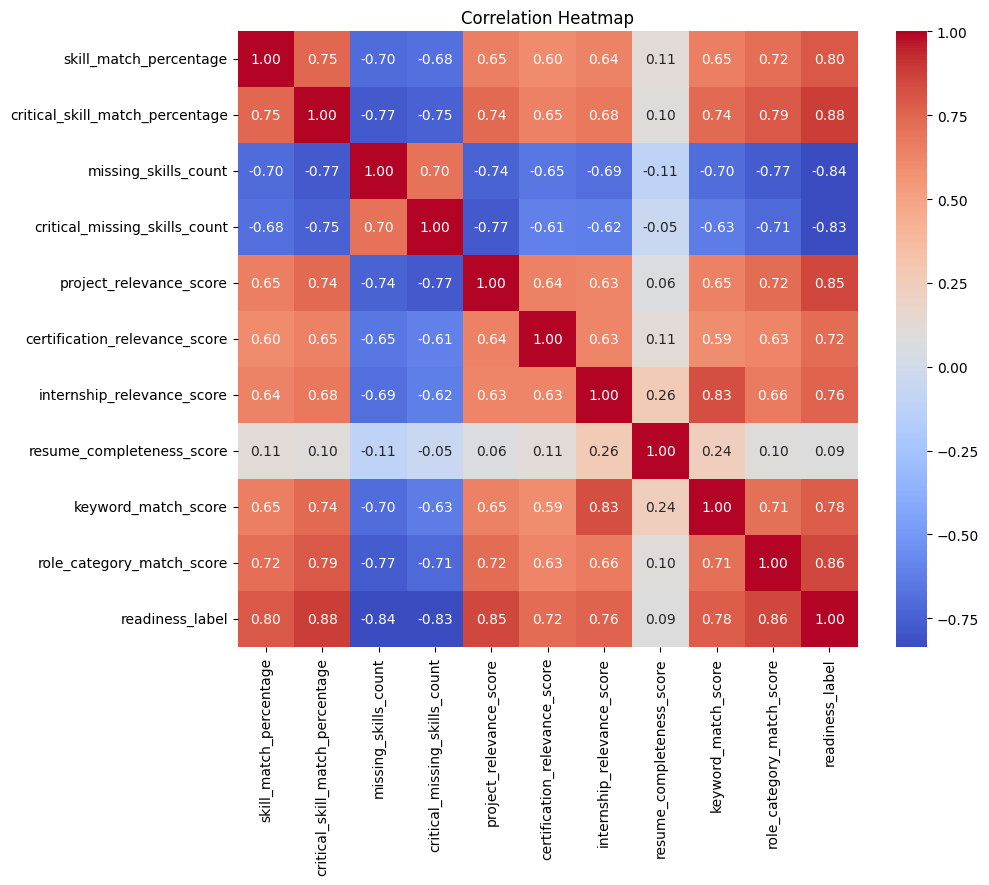

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

**2.4 Distribution of Readiness Label (Target)**

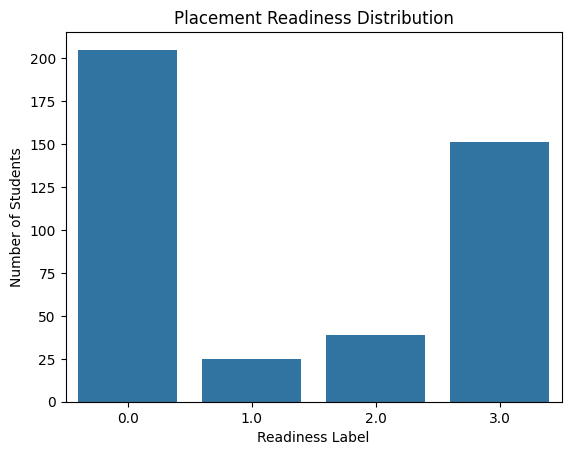

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="readiness_label", data=df)

plt.title("Placement Readiness Distribution")
plt.xlabel("Readiness Label")
plt.ylabel("Number of Students")

plt.show()

**2.5 Distribution of Numerical Features**

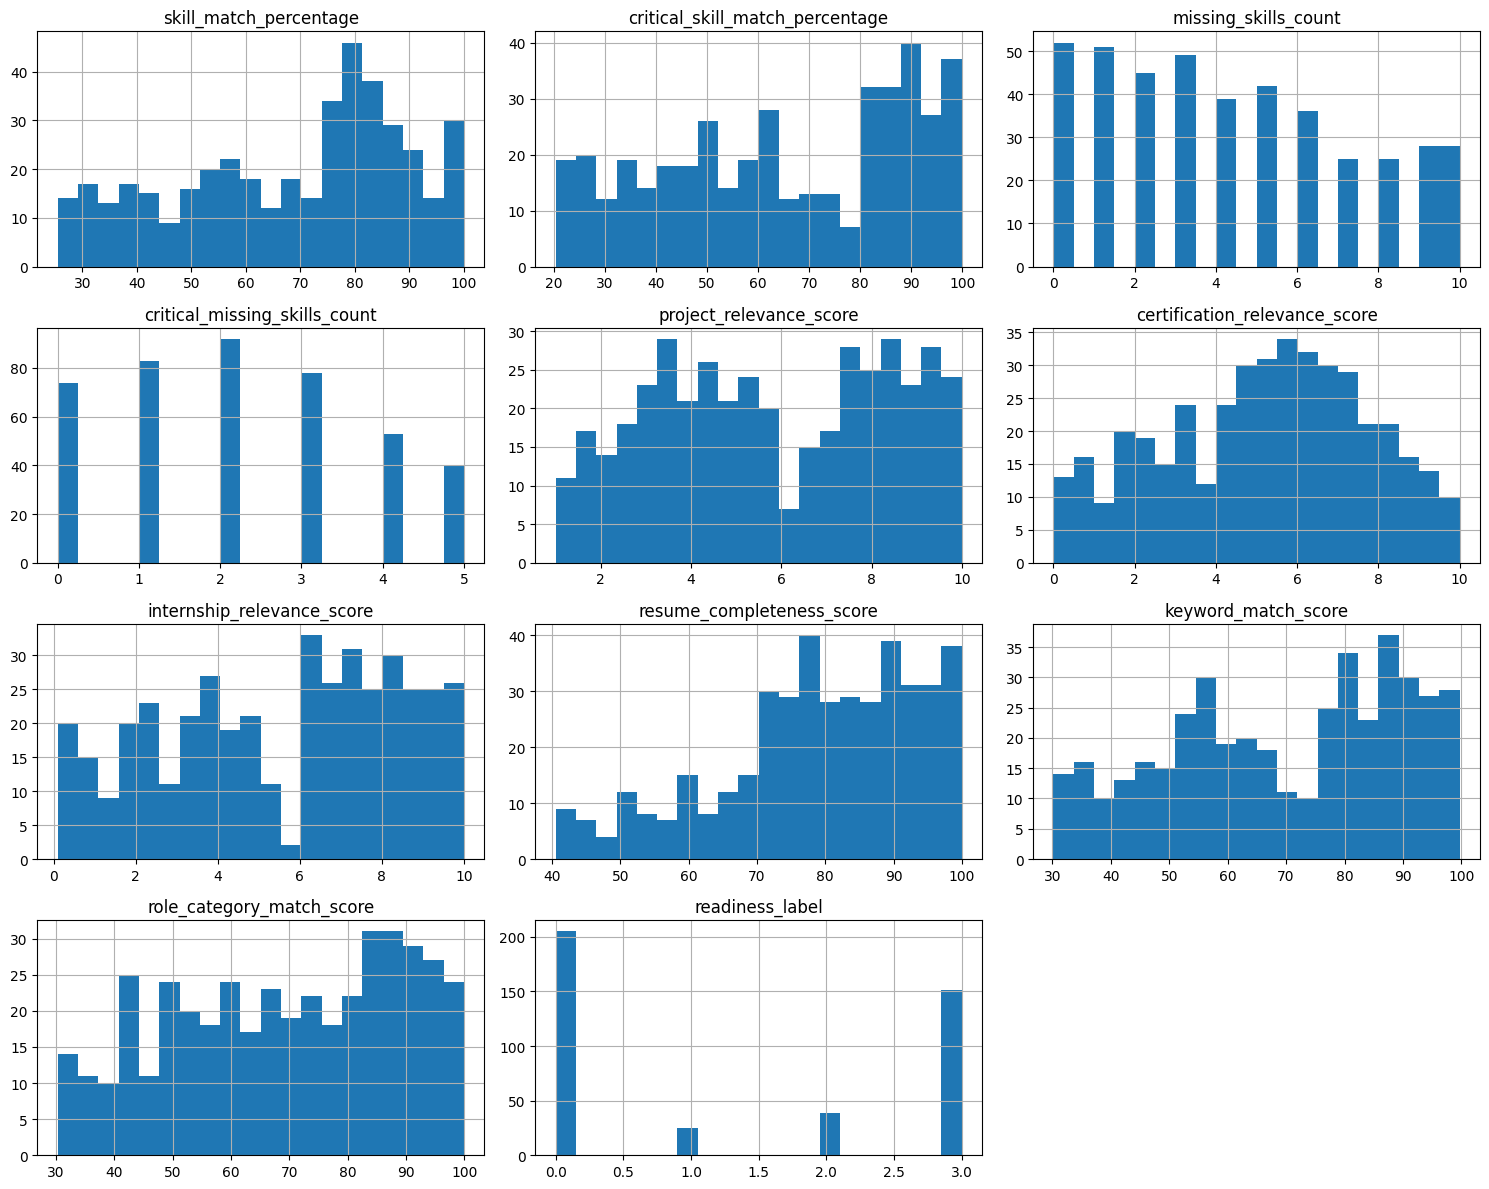

In [8]:
df.hist(
    figsize=(15,12),
    bins=20
)

plt.tight_layout()
plt.show()

**2.6 Boxplots for Outlier Detection**

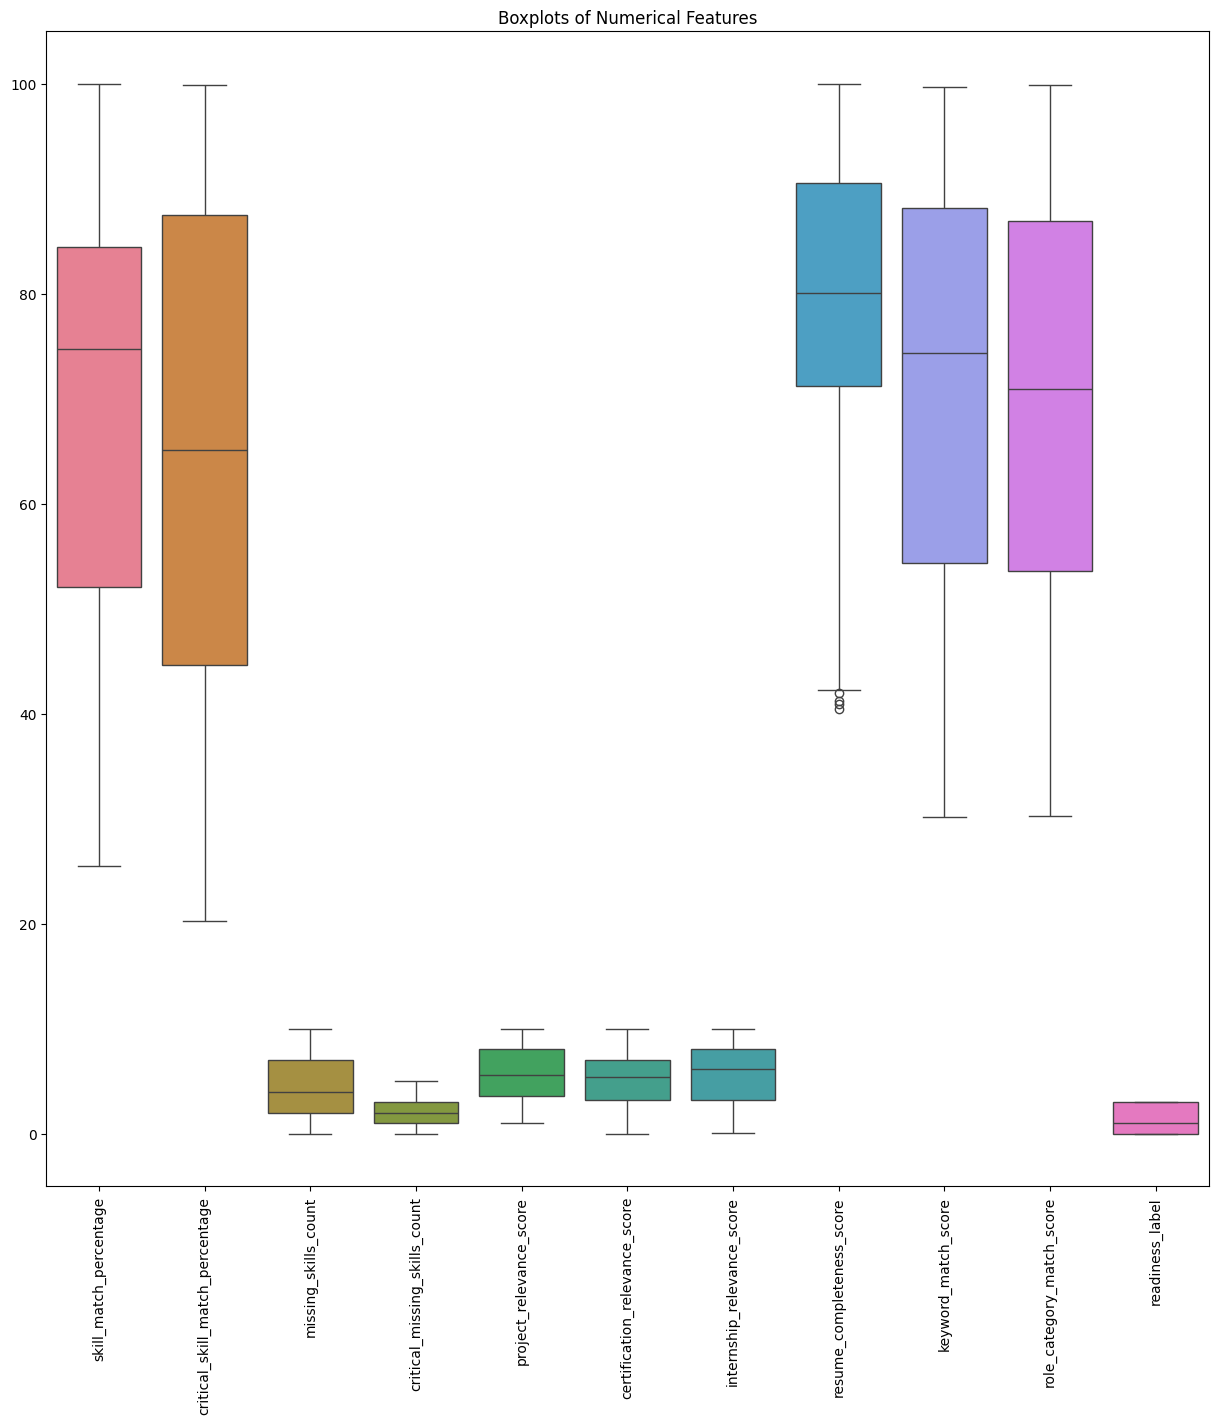

In [9]:
plt.figure(figsize=(15,15))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.title("Boxplots of Numerical Features")

plt.show()

In [10]:
# Independent Variables (Features)
X = df.drop("readiness_label", axis=1)

# Dependent Variable (Target)
y = df["readiness_label"]

print("Feature Matrix Shape:", X.shape)
print("Target Vector Shape:", y.shape)

print("\nFeature Names:")
print(X.columns.tolist())

Feature Matrix Shape: (420, 10)
Target Vector Shape: (420,)

Feature Names:
['skill_match_percentage', 'critical_skill_match_percentage', 'missing_skills_count', 'critical_missing_skills_count', 'project_relevance_score', 'certification_relevance_score', 'internship_relevance_score', 'resume_completeness_score', 'keyword_match_score', 'role_category_match_score']


**NOTE:**
These are stored in X, which represents the independent variables. The last column, readiness_label, is the target variable, stored in y. The model uses X to learn patterns and predict y. We remove readiness_label from X because it is the answer we want the model to predict. Including it in the inputs would cause data leakage and make the model unrealistically accurate."

In [11]:
print(X.shape)

(420, 10)


In [12]:
print(y.shape)

(420,)


# Train, Test - Split

"stratify=y ensures that the training and testing datasets maintain the same class distribution (percentage of each class) as the original dataset."

"random_state=42 ensures that the data is split the same way every time the code is run, making the results reproducible."

In [13]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Feature Shape:", X_train.shape)
print("Testing Feature Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Feature Shape: (336, 10)
Testing Feature Shape: (84, 10)
Training Target Shape: (336,)
Testing Target Shape: (84,)


# Feature Scaling

In [14]:
from sklearn.preprocessing import StandardScaler

# Create StandardScaler object
scaler = StandardScaler()

# Fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Training Data Shape:", X_train_scaled.shape)
print("Testing Data Shape:", X_test_scaled.shape)

Training Data Shape: (336, 10)
Testing Data Shape: (84, 10)


Feature scaling is the process of bringing all numerical features to a similar scale so that no feature dominates the others because of its larger values.

# Training Models

# Model 1: Logistic Regression

In [15]:
from sklearn.linear_model import LogisticRegression

# Create the model
lr_model = LogisticRegression(random_state=42)

# Train the model
lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


"fit() trains the machine learning model by learning the relationship between the input features (X_train) and the target variable (y_train)."`

In [16]:
y_pred = lr_model.predict(X_test_scaled)
print("Predicted Values:")
print(y_pred)

Predicted Values:
[0. 3. 0. 3. 2. 0. 0. 0. 0. 0. 0. 3. 3. 3. 0. 0. 2. 3. 3. 0. 3. 1. 3. 3.
 3. 0. 0. 0. 2. 2. 0. 3. 0. 0. 3. 0. 0. 3. 0. 0. 2. 0. 3. 3. 0. 1. 0. 0.
 3. 0. 0. 3. 2. 3. 3. 0. 3. 0. 0. 0. 3. 3. 0. 3. 0. 0. 3. 0. 0. 3. 2. 0.
 0. 3. 3. 3. 0. 3. 0. 0. 0. 0. 3. 2.]


# Model Evaluation

In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Precision
precision = precision_score(y_test, y_pred, average="weighted")
print("Precision:", precision)

# Recall
recall = recall_score(y_test, y_pred, average="weighted")
print("Recall:", recall)

# F1 Score
f1 = f1_score(y_test, y_pred, average="weighted")
print("F1 Score:", f1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred,  target_names=[
        "Not Ready Yet",
        "Needs Improvement",
        "Moderately Ready",
        "Highly Ready"]
))

Accuracy: 0.9523809523809523
Precision: 0.9538723966705963
Recall: 0.9523809523809523
F1 Score: 0.9451089178840936

Confusion Matrix:
[[41  0  0  0]
 [ 2  2  1  0]
 [ 0  0  7  1]
 [ 0  0  0 30]]

Classification Report:
                   precision    recall  f1-score   support

    Not Ready Yet       0.95      1.00      0.98        41
Needs Improvement       1.00      0.40      0.57         5
 Moderately Ready       0.88      0.88      0.88         8
     Highly Ready       0.97      1.00      0.98        30

         accuracy                           0.95        84
        macro avg       0.95      0.82      0.85        84
     weighted avg       0.95      0.95      0.95        84



****
**Accuracy is the percentage of correctly predicted observations out of the total observations.**
****
**Precision tells us how often the model's positive predictions are correct.**
****
**Recall measures how many of the actual positive cases were correctly identified by the model.**
****
**F1-Score is the harmonic mean of Precision and Recall and provides a balanced measure of a model's performance.**
****

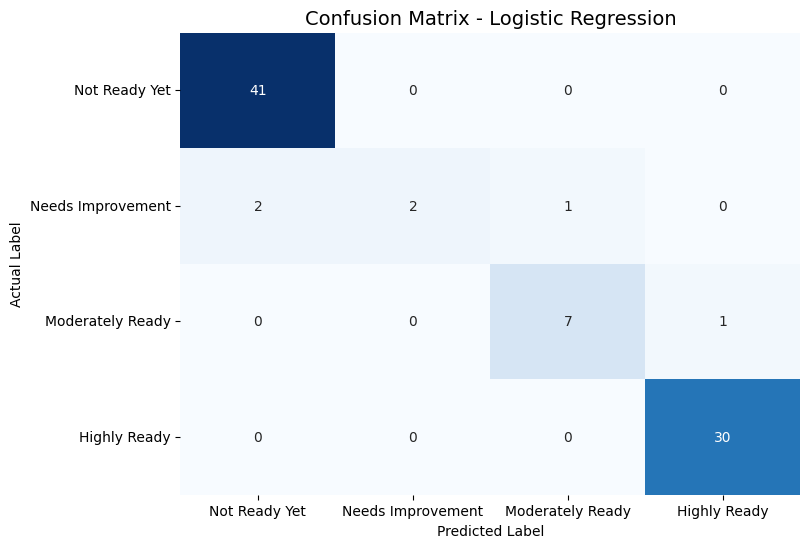

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Class Labels
labels = [
    "Not Ready Yet",
    "Needs Improvement",
    "Moderately Ready",
    "Highly Ready"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Confusion Matrix - Logistic Regression", fontsize=14)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [19]:
print(cm)
print(cm.shape)

[[41  0  0  0]
 [ 2  2  1  0]
 [ 0  0  7  1]
 [ 0  0  0 30]]
(4, 4)


# Selection of the Final Model

**The dataset used in this project is synthetically generated with clear relationships between the features and the target label. Logistic Regression was able to learn these patterns effectively and achieved 100% performance. Therefore, it was selected as the final model, and additional classification algorithms were not explored.**

# Saving the Trained Model

In [ ]:
#import joblib

# Save the trained Logistic Regression model
#joblib.dump(lr_model, "placement_readiness_model.pkl")

# Save the StandardScaler
#joblib.dump(scaler, "scaler.pkl")

#print("Model and Scaler saved successfully!")

Model and Scaler saved successfully!


****
The trained model was saved so it can be reused for predictions without retraining every time, making the application faster and more efficient.
****
The scaler was saved because new input data must be transformed using the same scaling parameters that were learned from the training data. This ensures consistency between training and prediction.
****

# Loading the Trained Model

In [21]:
import joblib
import pandas as pd

# Load trained model
model = joblib.load("placement_readiness_model.pkl")

# Load scaler
scaler = joblib.load("scaler.pkl")

print("Model and Scaler loaded successfully!")

Model and Scaler loaded successfully!


# Model 2: DecisionTreeClassifier

In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
#import joblib

# Create and train the Decision Tree model
dt_model = DecisionTreeClassifier(class_weight="balanced", random_state=42)
dt_model.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred_dt = dt_model.predict(X_test_scaled)

print("--- Decision Tree Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_dt, zero_division=0))

# Save separately
#joblib.dump(dt_model, "models/decision_tree_model.pkl")
#print("✅ Saved decision_tree_model.pkl successfully!")

--- Decision Tree Results ---
Accuracy: 0.9405

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98        41
         1.0       0.75      0.60      0.67         5
         2.0       0.88      0.88      0.88         8
         3.0       0.94      0.97      0.95        30

    accuracy                           0.94        84
   macro avg       0.88      0.85      0.87        84
weighted avg       0.94      0.94      0.94        84



# Model 3: RandomForestClassifier

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
#import joblib

# Create and train the Random Forest model
rf_model = RandomForestClassifier(class_weight="balanced", random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred_rf = rf_model.predict(X_test_scaled)

print("--- Random Forest Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

# Save separately
#joblib.dump(rf_model, "models/random_forest_model.pkl")
#print("✅ Saved random_forest_model.pkl successfully!")

--- Random Forest Results ---
Accuracy: 0.9405

Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.95      0.96        41
         1.0       0.60      0.60      0.60         5
         2.0       0.80      1.00      0.89         8
         3.0       1.00      0.97      0.98        30

    accuracy                           0.94        84
   macro avg       0.84      0.88      0.86        84
weighted avg       0.94      0.94      0.94        84



# Model 4: GradientBoostingClassifier

In [24]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
#import joblib

# Create and train the Gradient Boosting model
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred_gb = gb_model.predict(X_test_scaled)

print("--- Gradient Boosting Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_gb, zero_division=0))

# Save separately
#joblib.dump(gb_model, "models/gradient_boosting_model.pkl")
#print("✅ Saved gradient_boosting_model.pkl successfully!")

--- Gradient Boosting Results ---
Accuracy: 0.9286

Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.95      0.96        41
         1.0       0.50      0.60      0.55         5
         2.0       0.86      0.75      0.80         8
         3.0       0.97      1.00      0.98        30

    accuracy                           0.93        84
   macro avg       0.82      0.83      0.82        84
weighted avg       0.93      0.93      0.93        84



# Comparison Table of all the Models 

In [25]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Gather predictions from all trained models
model_predictions = {
    "Logistic Regression": lr_model.predict(X_test_scaled),
    "Decision Tree": dt_model.predict(X_test_scaled),
    "Random Forest": rf_model.predict(X_test_scaled),
    "Gradient Boosting": gb_model.predict(X_test_scaled)
}

comparison_data = []

for name, y_pred in model_predictions.items():
    comparison_data.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision (Weighted)": round(precision_score(y_test, y_pred, average="weighted", zero_division=0), 4),
        "Recall (Weighted)": round(recall_score(y_test, y_pred, average="weighted", zero_division=0), 4),
        "F1-Score (Weighted)": round(f1_score(y_test, y_pred, average="weighted", zero_division=0), 4)
    })

# Convert to DataFrame for a clean tabular display
comparison_df = pd.DataFrame(comparison_data)

# Display the table
print(comparison_df.to_string(index=False))

              Model  Accuracy  Precision (Weighted)  Recall (Weighted)  F1-Score (Weighted)
Logistic Regression    0.9524                0.9539             0.9524               0.9451
      Decision Tree    0.9405                0.9383             0.9405               0.9388
      Random Forest    0.9405                0.9449             0.9405               0.9415
  Gradient Boosting    0.9286                0.9329             0.9286               0.9300


In [27]:
from pathlib import Path

# Define the path to the old model file
old_model_path = Path("models/placement_readiness_model.pkl")

# Delete it if it exists
if old_model_path.exists():
    old_model_path.unlink()
    print("🗑️ Previously saved model deleted successfully!")
else:
    print("ℹ️ No previous model found to delete.")

🗑️ Previously saved model deleted successfully!


In [28]:
import joblib

# Save the Random Forest model into the models folder with the deployment filename
joblib.dump(rf_model, "models/placement_readiness_model.pkl")

# Save the StandardScaler as well
joblib.dump(scaler, "models/scaler.pkl")

print("✅ Random Forest model successfully saved as 'placement_readiness_model.pkl' in the models/ folder!")

✅ Random Forest model successfully saved as 'placement_readiness_model.pkl' in the models/ folder!
